In [ ]:
import pandas as pd
import glob
import os

# Find CSV files in the current Colab folder
files = glob.glob("atp_matches_*.csv")

print("Files found:")
for f in files:
    print(f)

# Load all CSV files
dfs = []

for f in files:
    
    df = pd.read_csv(f)

    # Extract year from filename
    year = int(os.path.basename(f).split("_")[-1].replace(".csv", ""))
    df["year"] = year

    dfs.append(df)

# Combine all years
data = pd.concat(dfs, ignore_index=True)

print("\nDataset shape:", data.shape)

print("\nColumns:")
print(data.columns.tolist())

Files found:
atp_matches_2021.csv
atp_matches_2020.csv
atp_matches_2018.csv
atp_matches_2023.csv
atp_matches_2022.csv
atp_matches_2024.csv
atp_matches_2019.csv

Dataset shape: (18877, 50)

Columns:
['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level', 'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry', 'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age', 'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand', 'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of', 'round', 'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced', 'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points', 'year']


In [ ]:
data.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points,year
0,2021-0096,Tokyo Olympics,Hard,64,A,20210724,237,126207,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,53.0,1228.0,71.0,996.0,2021
1,2021-0096,Tokyo Olympics,Hard,64,A,20210724,238,105526,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,48.0,1410.0,95.0,829.0,2021
2,2021-0096,Tokyo Olympics,Hard,64,A,20210724,239,111576,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,160.0,471.0,197.0,354.0,2021
3,2021-0096,Tokyo Olympics,Hard,64,A,20210724,240,105357,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,44.0,1476.0,61.0,1106.0,2021
4,2021-0096,Tokyo Olympics,Hard,64,A,20210724,241,207830,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,145.0,525.0,137.0,570.0,2021


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18877 entries, 0 to 18876
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          18877 non-null  object 
 1   tourney_name        18877 non-null  object 
 2   surface             18824 non-null  object 
 3   draw_size           18877 non-null  int64  
 4   tourney_level       18877 non-null  object 
 5   tourney_date        18877 non-null  int64  
 6   match_num           18877 non-null  int64  
 7   winner_id           18877 non-null  int64  
 8   winner_seed         7773 non-null   float64
 9   winner_entry        2885 non-null   object 
 10  winner_name         18877 non-null  object 
 11  winner_hand         18877 non-null  object 
 12  winner_ht           18798 non-null  float64
 13  winner_ioc          18877 non-null  object 
 14  winner_age          18874 non-null  float64
 15  loser_id            18877 non-null  int64  
 16  lose

In [ ]:
# Check missing values
missing = data.isnull().sum()

# Show only columns that have missing values
missing[missing > 0].sort_values(ascending=False)

,0
winner_entry,15992
loser_entry,14534
loser_seed,14207
winner_seed,11104
minutes,1033
l_2ndWon,694
w_svpt,694
w_ace,694
w_df,694
w_1stWon,694


In [ ]:
# Basic dataset statistics
print("Number of matches:", len(data))
print("Number of features:", len(data.columns))

print("\nSurface types:")
print(data["surface"].value_counts())

print("\nYears:")
print(data["year"].value_counts().sort_index())

Number of matches: 18877
Number of features: 50

Surface types:
surface
Hard     11206
Clay      5669
Grass     1949
Name: count, dtype: int64

Years:
year
2018    2897
2019    2806
2020    1462
2021    2733
2022    2917
2023    2986
2024    3076
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Select only pre-match information
matches = data[
    [
        "winner_name",
        "loser_name",
        "winner_rank",
        "loser_rank",
        "winner_rank_points",
        "loser_rank_points",
        "winner_age",
        "loser_age",
        "surface",
        "year"
    ]
].copy()

# Remove matches where essential ranking information is missing
matches = matches.dropna(
    subset=[
        "winner_rank",
        "loser_rank",
        "winner_rank_points",
        "loser_rank_points"
    ]
)

print("Matches after cleaning:", len(matches))
print("\nMissing values:")
print(matches.isnull().sum())

Matches after cleaning: 18608

Missing values:
winner_name            0
loser_name             0
winner_rank            0
loser_rank             0
winner_rank_points     0
loser_rank_points      0
winner_age             0
loser_age              0
surface               36
year                   0
dtype: int64


In [ ]:
# Create numerical difference features

matches["rank_diff"] = (
    matches["winner_rank"] - matches["loser_rank"]
)

matches["rank_points_diff"] = (
    matches["winner_rank_points"] - matches["loser_rank_points"]
)

matches["age_diff"] = (
    matches["winner_age"] - matches["loser_age"]
)

# Keep only the features we need
ml_data = matches[
    [
        "rank_diff",
        "rank_points_diff",
        "age_diff",
        "surface",
        "year"
    ]
].copy()

# Handle missing age values
ml_data["age_diff"] = ml_data["age_diff"].fillna(
    ml_data["age_diff"].median()
)

print(ml_data.head())
print("\nShape:", ml_data.shape)

   rank_diff  rank_points_diff  age_diff surface  year
0      -18.0             232.0      -0.2    Hard  2021
1      -47.0             581.0       4.1    Hard  2021
2      -37.0             117.0     -10.9    Hard  2021
3      -17.0             370.0      12.7    Hard  2021
4        8.0             -45.0     -11.6    Hard  2021

Shape: (18608, 5)


In [ ]:
# Create two training examples per match

player1 = matches.copy()

player1["rank_diff"] = (
    player1["winner_rank"] - player1["loser_rank"]
)

player1["rank_points_diff"] = (
    player1["winner_rank_points"] -
    player1["loser_rank_points"]
)

player1["age_diff"] = (
    player1["winner_age"] -
    player1["loser_age"]
)

player1["target"] = 1


# Reverse the players
player2 = matches.copy()

player2["rank_diff"] = (
    player2["loser_rank"] - player2["winner_rank"]
)

player2["rank_points_diff"] = (
    player2["loser_rank_points"] -
    player2["winner_rank_points"]
)

player2["age_diff"] = (
    player2["loser_age"] -
    player2["winner_age"]
)

player2["target"] = 0


# Select required columns
player1 = player1[
    ["rank_diff", "rank_points_diff", "age_diff",
     "surface", "year", "target"]
]

player2 = player2[
    ["rank_diff", "rank_points_diff", "age_diff",
     "surface", "year", "target"]
]


# Combine
ml_data = pd.concat(
    [player1, player2],
    ignore_index=True
)

# Handle missing age differences
ml_data["age_diff"] = ml_data["age_diff"].fillna(
    ml_data["age_diff"].median()
)

print("Final ML dataset shape:", ml_data.shape)

print("\nTarget distribution:")
print(ml_data["target"].value_counts())

print("\nSample:")
print(ml_data.head())

Final ML dataset shape: (37216, 6)

Target distribution:
target
1    18608
0    18608
Name: count, dtype: int64

Sample:
   rank_diff  rank_points_diff  age_diff surface  year  target
0      -18.0             232.0      -0.2    Hard  2021       1
1      -47.0             581.0       4.1    Hard  2021       1
2      -37.0             117.0     -10.9    Hard  2021       1
3      -17.0             370.0      12.7    Hard  2021       1
4        8.0             -45.0     -11.6    Hard  2021       1


In [ ]:
# Chronological train-test split

train_data = ml_data[ml_data["year"] < 2024].copy()
test_data = ml_data[ml_data["year"] == 2024].copy()

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

print("\nTraining years:")
print(sorted(train_data["year"].unique()))

print("\nTesting years:")
print(sorted(test_data["year"].unique()))

Training samples: 31156
Testing samples: 6060

Training years:
[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Testing years:
[np.int64(2024)]


In [ ]:
# ==========================================
# STEP 7: TRAIN 3 MACHINE LEARNING MODELS
# ==========================================

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------
# 1. Separate features and target
# ------------------------------------------

X_train = train_data.drop(columns=["target"])
y_train = train_data["target"]

X_test = test_data.drop(columns=["target"])
y_test = test_data["target"]


# ------------------------------------------
# 2. Identify categorical and numerical data
# ------------------------------------------

categorical_features = ["surface"]

numerical_features = [
    "rank_diff",
    "rank_points_diff",
    "age_diff"
]


# ------------------------------------------
# 3. Preprocessing
# ------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)


# ------------------------------------------
# 4. Define models
# ------------------------------------------

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    )
}


# ------------------------------------------
# 5. Train and evaluate
# ------------------------------------------

results = []

trained_models = {}

for name, model in models.items():

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    trained_models[name] = pipeline


# ------------------------------------------
# 6. Results table
# ------------------------------------------

results_df = pd.DataFrame(results)

print("\n\nFINAL MODEL COMPARISON")
print("=" * 70)

display(
    results_df.sort_values(
        by="Accuracy",
        ascending=False
    )
)


Logistic Regression
Accuracy  : 0.6360
Precision : 0.6360
Recall    : 0.6360
F1 Score  : 0.6360

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.64      0.64      3030
           1       0.64      0.64      0.64      3030

    accuracy                           0.64      6060
   macro avg       0.64      0.64      0.64      6060
weighted avg       0.64      0.64      0.64      6060


Random Forest
Accuracy  : 0.6038
Precision : 0.6047
Recall    : 0.5997
F1 Score  : 0.6022

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.61      0.61      3030
           1       0.60      0.60      0.60      3030

    accuracy                           0.60      6060
   macro avg       0.60      0.60      0.60      6060
weighted avg       0.60      0.60      0.60      6060


SVM
Accuracy  : 0.6370
Precision : 0.6370
Recall    : 0.6370
F1 Score  : 0.6370

Classification Report:
     

,Model,Accuracy,Precision,Recall,F1 Score
2,SVM,0.636964,0.636964,0.636964,0.636964
0,Logistic Regression,0.635974,0.635974,0.635974,0.635974
1,Random Forest,0.603795,0.604659,0.599670,0.602154



Logistic Regression
[[1927 1103]
 [1103 1927]]


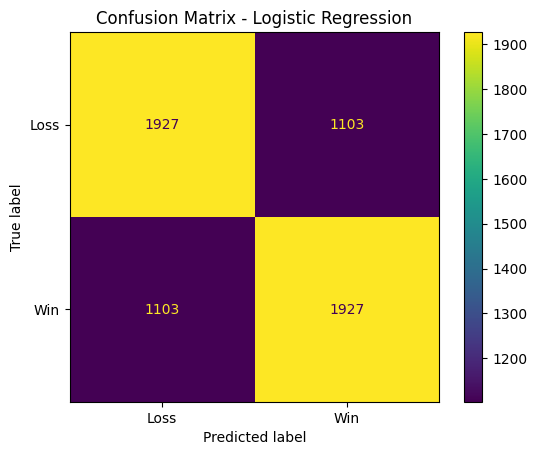


Random Forest
[[1842 1188]
 [1213 1817]]


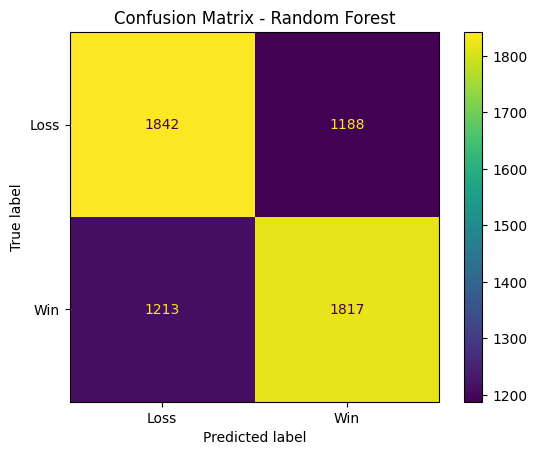


SVM
[[1930 1100]
 [1100 1930]]


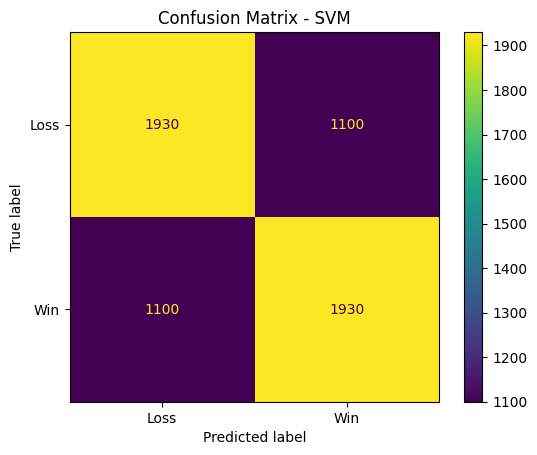

In [ ]:
# ==========================================
# STEP 8: CONFUSION MATRICES
# ==========================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    cm = confusion_matrix(y_test, y_pred)

    print(cm)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Loss", "Win"]
    ).plot()

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

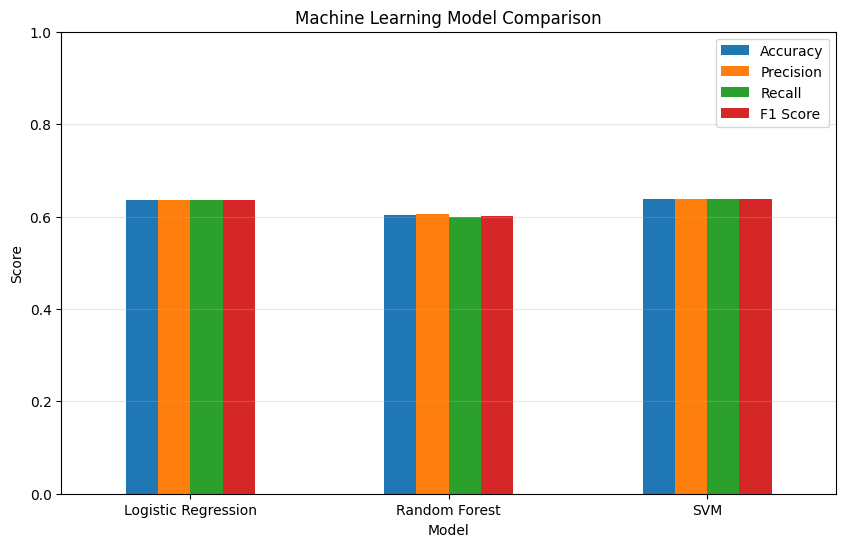

In [ ]:
# ==========================================
# STEP 9: MODEL COMPARISON
# ==========================================

import matplotlib.pyplot as plt

comparison = results_df.set_index("Model")

comparison[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
# ==========================================
# STEP 10A: HISTORICAL PLAYER FORM
# ==========================================

import pandas as pd
import numpy as np

# Work on the original chronological dataset
history_data = data.copy()

# Make sure matches are in chronological order
history_data = history_data.sort_values(
    by=["year", "tourney_date"]
).reset_index(drop=True)

# Dictionaries to store player history
player_stats = {}

# Store head-to-head records
h2h = {}

# Store generated training rows
historical_rows = []


def get_player_stats(player_id):
    """Return player's historical statistics."""

    if player_id not in player_stats:
        player_stats[player_id] = {
            "matches": 0,
            "wins": 0,
            "surface_matches": {},
            "surface_wins": {}
        }

    return player_stats[player_id]


def get_h2h(player1, player2):
    """Return previous head-to-head wins for player1 against player2."""

    key = tuple(sorted([player1, player2]))

    if key not in h2h:
        h2h[key] = {
            player1: 0,
            player2: 0
        }

    return h2h[key].get(player1, 0)


# Process every match chronologically
for _, row in history_data.iterrows():

    winner = row["winner_id"]
    loser = row["loser_id"]
    surface = row["surface"]

    # Skip rows without player IDs
    if pd.isna(winner) or pd.isna(loser):
        continue

    # Get statistics BEFORE this match
    w_stats = get_player_stats(winner)
    l_stats = get_player_stats(loser)

    # Overall win rates
    winner_win_rate = (
        w_stats["wins"] / w_stats["matches"]
        if w_stats["matches"] > 0 else 0.5
    )

    loser_win_rate = (
        l_stats["wins"] / l_stats["matches"]
        if l_stats["matches"] > 0 else 0.5
    )

    # Surface statistics
    w_surface_matches = w_stats["surface_matches"].get(surface, 0)
    w_surface_wins = w_stats["surface_wins"].get(surface, 0)

    l_surface_matches = l_stats["surface_matches"].get(surface, 0)
    l_surface_wins = l_stats["surface_wins"].get(surface, 0)

    winner_surface_rate = (
        w_surface_wins / w_surface_matches
        if w_surface_matches > 0 else 0.5
    )

    loser_surface_rate = (
        l_surface_wins / l_surface_matches
        if l_surface_matches > 0 else 0.5
    )

    # Head-to-head
    winner_h2h = get_h2h(winner, loser)
    loser_h2h = get_h2h(loser, winner)

    # Create winner perspective
    historical_rows.append({
        "player1": winner,
        "player2": loser,
        "surface": surface,
        "winner_rank": row["winner_rank"],
        "loser_rank": row["loser_rank"],
        "winner_rank_points": row["winner_rank_points"],
        "loser_rank_points": row["loser_rank_points"],
        "winner_age": row["winner_age"],
        "loser_age": row["loser_age"],
        "player1_win_rate": winner_win_rate,
        "player2_win_rate": loser_win_rate,
        "player1_surface_rate": winner_surface_rate,
        "player2_surface_rate": loser_surface_rate,
        "player1_h2h": winner_h2h,
        "player2_h2h": loser_h2h,
        "target": 1,
        "year": row["year"]
    })

    # Create loser perspective
    historical_rows.append({
        "player1": loser,
        "player2": winner,
        "surface": surface,
        "winner_rank": row["loser_rank"],
        "loser_rank": row["winner_rank"],
        "winner_rank_points": row["loser_rank_points"],
        "loser_rank_points": row["winner_rank_points"],
        "winner_age": row["loser_age"],
        "loser_age": row["winner_age"],
        "player1_win_rate": loser_win_rate,
        "player2_win_rate": winner_win_rate,
        "player1_surface_rate": loser_surface_rate,
        "player2_surface_rate": winner_surface_rate,
        "player1_h2h": loser_h2h,
        "player2_h2h": winner_h2h,
        "target": 0,
        "year": row["year"]
    })

    # --------------------------------------
    # UPDATE HISTORY AFTER the match
    # --------------------------------------

    w_stats["matches"] += 1
    w_stats["wins"] += 1

    l_stats["matches"] += 1

    w_stats["surface_matches"][surface] = \
        w_stats["surface_matches"].get(surface, 0) + 1

    w_stats["surface_wins"][surface] = \
        w_stats["surface_wins"].get(surface, 0) + 1

    l_stats["surface_matches"][surface] = \
        l_stats["surface_matches"].get(surface, 0) + 1

    # Update H2H
    key = tuple(sorted([winner, loser]))

    if key not in h2h:
        h2h[key] = {
            winner: 0,
            loser: 0
        }

    h2h[key][winner] = h2h[key].get(winner, 0) + 1


# Convert to DataFrame
historical_data = pd.DataFrame(historical_rows)

print("Historical dataset shape:", historical_data.shape)

print("\nColumns:")
print(historical_data.columns.tolist())

print("\nSample:")
display(historical_data.head())

Historical dataset shape: (37754, 17)

Columns:
['player1', 'player2', 'surface', 'winner_rank', 'loser_rank', 'winner_rank_points', 'loser_rank_points', 'winner_age', 'loser_age', 'player1_win_rate', 'player2_win_rate', 'player1_surface_rate', 'player2_surface_rate', 'player1_h2h', 'player2_h2h', 'target', 'year']

Sample:


,player1,player2,surface,winner_rank,loser_rank,winner_rank_points,loser_rank_points,winner_age,loser_age,player1_win_rate,player2_win_rate,player1_surface_rate,player2_surface_rate,player1_h2h,player2_h2h,target,year
0,105992,104919,Hard,47.0,52.0,1010.0,909.0,25.6,30.6,0.5,0.5,0.5,0.5,0,0,1,2018
1,104919,105992,Hard,52.0,47.0,909.0,1010.0,30.6,25.6,0.5,0.5,0.5,0.5,0,0,0,2018
2,111577,111442,Hard,54.0,94.0,890.0,593.0,21.2,23.7,0.5,0.5,0.5,0.5,0,0,1,2018
3,111442,111577,Hard,94.0,54.0,593.0,890.0,23.7,21.2,0.5,0.5,0.5,0.5,0,0,0,2018
4,104797,106000,Hard,63.0,30.0,809.0,1391.0,31.3,25.6,0.5,0.5,0.5,0.5,0,0,1,2018


In [ ]:
# ==========================================
# STEP 10B: FEATURE ENGINEERING
# ==========================================

improved_data = pd.DataFrame()

improved_data["rank_diff"] = (
    historical_data["winner_rank"] -
    historical_data["loser_rank"]
)

improved_data["rank_points_diff"] = (
    historical_data["winner_rank_points"] -
    historical_data["loser_rank_points"]
)

improved_data["age_diff"] = (
    historical_data["winner_age"] -
    historical_data["loser_age"]
)

improved_data["win_rate_diff"] = (
    historical_data["player1_win_rate"] -
    historical_data["player2_win_rate"]
)

improved_data["surface_rate_diff"] = (
    historical_data["player1_surface_rate"] -
    historical_data["player2_surface_rate"]
)

improved_data["h2h_diff"] = (
    historical_data["player1_h2h"] -
    historical_data["player2_h2h"]
)

improved_data["surface"] = historical_data["surface"]
improved_data["year"] = historical_data["year"]
improved_data["target"] = historical_data["target"]

# Handle missing numeric values
numeric_cols = [
    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "win_rate_diff",
    "surface_rate_diff",
    "h2h_diff"
]

for col in numeric_cols:
    improved_data[col] = improved_data[col].fillna(
        improved_data[col].median()
    )

print("Improved dataset shape:", improved_data.shape)

display(improved_data.head())

Improved dataset shape: (37754, 9)


,rank_diff,rank_points_diff,age_diff,win_rate_diff,surface_rate_diff,h2h_diff,surface,year,target
0,-5.0,101.0,-5.0,0.0,0.0,0,Hard,2018,1
1,5.0,-101.0,5.0,0.0,0.0,0,Hard,2018,0
2,-40.0,297.0,-2.5,0.0,0.0,0,Hard,2018,1
3,40.0,-297.0,2.5,0.0,0.0,0,Hard,2018,0
4,33.0,-582.0,5.7,0.0,0.0,0,Hard,2018,1


In [ ]:
# ==========================================
# STEP 10C: CHRONOLOGICAL SPLIT
# ==========================================

improved_train = improved_data[
    improved_data["year"] < 2024
].copy()

improved_test = improved_data[
    improved_data["year"] == 2024
].copy()

print("Training samples:", len(improved_train))
print("Testing samples:", len(improved_test))

print("\nTraining years:")
print(sorted(improved_train["year"].unique()))

print("\nTesting years:")
print(sorted(improved_test["year"].unique()))

Training samples: 31602
Testing samples: 6152

Training years:
[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Testing years:
[np.int64(2024)]


In [ ]:
# ==========================================
# STEP 11: TRAIN IMPROVED MODELS
# ==========================================

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import pandas as pd


# ------------------------------------------
# 1. Separate features and target
# ------------------------------------------

X_train_improved = improved_train.drop(
    columns=["target", "year"]
)

y_train_improved = improved_train["target"]

X_test_improved = improved_test.drop(
    columns=["target", "year"]
)

y_test_improved = improved_test["target"]


# ------------------------------------------
# 2. Features
# ------------------------------------------

numerical_features_improved = [
    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "win_rate_diff",
    "surface_rate_diff",
    "h2h_diff"
]

categorical_features_improved = [
    "surface"
]


# ------------------------------------------
# 3. Preprocessing
# ------------------------------------------

preprocessor_improved = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features_improved
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_improved
        )
    ]
)


# ------------------------------------------
# 4. Models
# ------------------------------------------

improved_models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    )
}


# ------------------------------------------
# 5. Train and evaluate
# ------------------------------------------

improved_results = []

improved_trained_models = {}

for name, model in improved_models.items():

    print("\n" + "=" * 55)
    print(name)
    print("=" * 55)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_improved),
            ("model", model)
        ]
    )

    # Train
    pipeline.fit(
        X_train_improved,
        y_train_improved
    )

    # Predict
    y_pred = pipeline.predict(
        X_test_improved
    )

    # Metrics
    accuracy = accuracy_score(
        y_test_improved,
        y_pred
    )

    precision = precision_score(
        y_test_improved,
        y_pred
    )

    recall = recall_score(
        y_test_improved,
        y_pred
    )

    f1 = f1_score(
        y_test_improved,
        y_pred
    )

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test_improved,
            y_pred
        )
    )

    improved_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    improved_trained_models[name] = pipeline


# ------------------------------------------
# 6. Results table
# ------------------------------------------

improved_results_df = pd.DataFrame(
    improved_results
)

print("\n\nIMPROVED MODEL COMPARISON")
print("=" * 70)

display(
    improved_results_df.sort_values(
        by="Accuracy",
        ascending=False
    )
)


Logistic Regression
Accuracy  : 0.6369
Precision : 0.6369
Recall    : 0.6369
F1 Score  : 0.6369

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.64      0.64      3076
           1       0.64      0.64      0.64      3076

    accuracy                           0.64      6152
   macro avg       0.64      0.64      0.64      6152
weighted avg       0.64      0.64      0.64      6152


Random Forest
Accuracy  : 0.6294
Precision : 0.6305
Recall    : 0.6252
F1 Score  : 0.6278

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.63      0.63      3076
           1       0.63      0.63      0.63      3076

    accuracy                           0.63      6152
   macro avg       0.63      0.63      0.63      6152
weighted avg       0.63      0.63      0.63      6152


SVM
Accuracy  : 0.6416
Precision : 0.6415
Recall    : 0.6417
F1 Score  : 0.6416

Classification Report:
     

,Model,Accuracy,Precision,Recall,F1 Score
2,SVM,0.641580,0.641534,0.641743,0.641638
0,Logistic Regression,0.636866,0.636866,0.636866,0.636866
1,Random Forest,0.629389,0.630492,0.625163,0.627816


                 Model  Baseline  Improved
0  Logistic Regression    0.6360  0.636866
1        Random Forest    0.6038  0.629389
2                  SVM    0.6370  0.641580


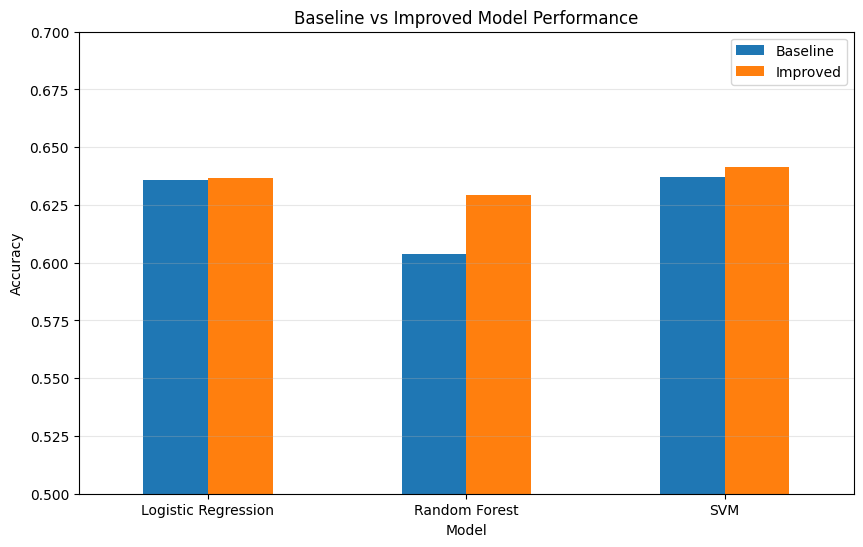

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Baseline results
baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Baseline": [
        0.6360,
        0.6038,
        0.6370
    ]
})

# Improved results
improved_plot = improved_results_df[
    ["Model", "Accuracy"]
].copy()

improved_plot = improved_plot.rename(
    columns={"Accuracy": "Improved"}
)

# Combine
comparison_final = baseline_results.merge(
    improved_plot,
    on="Model"
)

print(comparison_final)

# Plot
comparison_final.set_index("Model")[
    ["Baseline", "Improved"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline vs Improved Model Performance")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.ylim(0.5, 0.7)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.show()

SVM Confusion Matrix:
[[1973 1103]
 [1102 1974]]


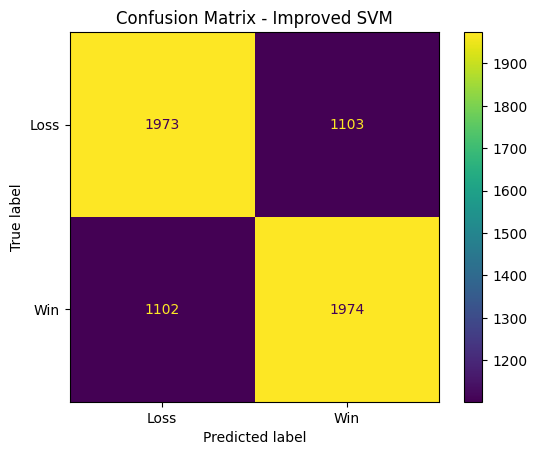

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions from improved SVM
best_model = improved_trained_models["SVM"]

y_pred_svm = best_model.predict(X_test_improved)

# Confusion matrix
cm = confusion_matrix(
    y_test_improved,
    y_pred_svm
)

print("SVM Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Loss", "Win"]
).plot()

plt.title("Confusion Matrix - Improved SVM")
plt.show()

In [ ]:
# ==========================================
# STEP 15: TEST FINAL MODEL
# ==========================================

import pandas as pd

# Example match
player1_rank = 5
player2_rank = 10

player1_points = 5000
player2_points = 3500

player1_age = 27
player2_age = 25

player1_win_rate = 0.70
player2_win_rate = 0.60

player1_surface_rate = 0.75
player2_surface_rate = 0.55

player1_h2h = 3
player2_h2h = 2

surface = "Hard"


# Create features
prediction_input = pd.DataFrame({
    "rank_diff": [
        player1_rank - player2_rank
    ],

    "rank_points_diff": [
        player1_points - player2_points
    ],

    "age_diff": [
        player1_age - player2_age
    ],

    "win_rate_diff": [
        player1_win_rate - player2_win_rate
    ],

    "surface_rate_diff": [
        player1_surface_rate - player2_surface_rate
    ],

    "h2h_diff": [
        player1_h2h - player2_h2h
    ],

    "surface": [
        surface
    ]
})


# Prediction
prediction = best_model.predict(
    prediction_input
)[0]

probability = best_model.predict_proba(
    prediction_input
)[0]


print("Prediction input:")
display(prediction_input)

print("\nPrediction:")

if prediction == 1:
    print("🏆 Player 1 is predicted to WIN")
else:
    print("🏆 Player 2 is predicted to WIN")

print("\nProbabilities:")
print(f"Player 1: {probability[1] * 100:.2f}%")
print(f"Player 2: {probability[0] * 100:.2f}%")

Prediction input:


,rank_diff,rank_points_diff,age_diff,win_rate_diff,surface_rate_diff,h2h_diff,surface
0,-5,1500,2,0.1,0.2,1,Hard



Prediction:
🏆 Player 1 is predicted to WIN

Probabilities:
Player 1: 71.68%
Player 2: 28.32%
